<a href="https://colab.research.google.com/github/Arya20040110/med_image_processing/blob/main/med_imageipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

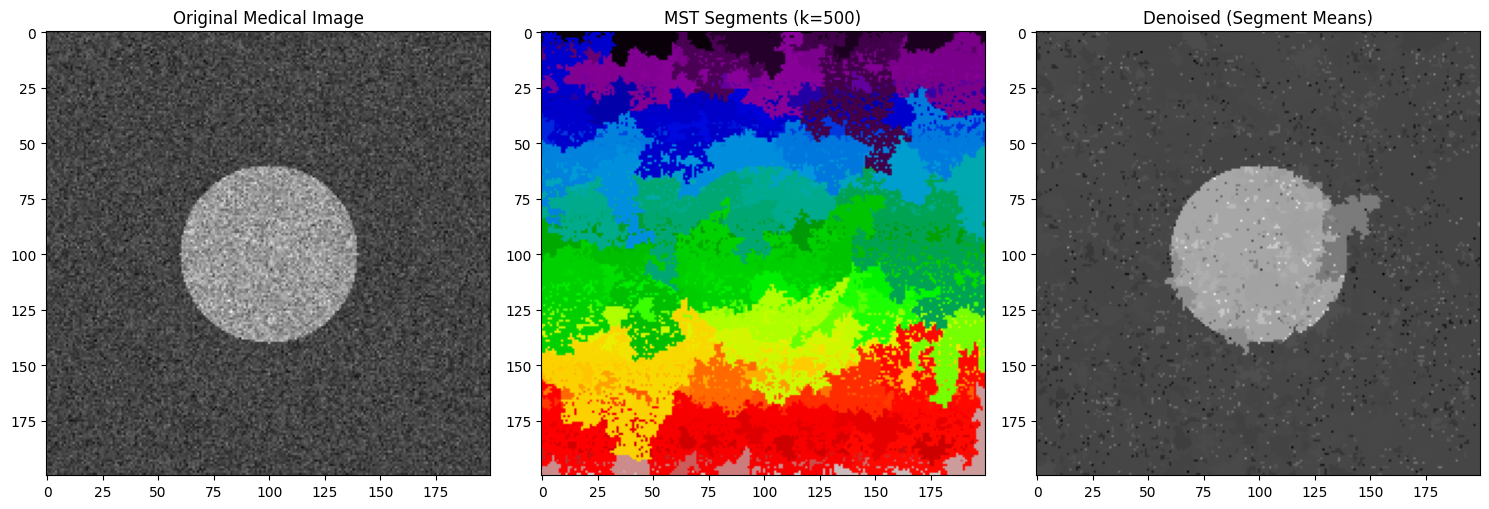

Segmentation completed in 0.5581 seconds.
Total Segments identified: 2253


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
import time

class UnionFind:
    """
    Implements the Union-Find data structure for component management.
    Includes tracking for component size and internal difference (max weight). # [cite: 104, 111]
    """
    def __init__(self, n):
        self.parent = np.arange(n)
        self.size = np.ones(n)
        self.max_weight = np.zeros(n)

    def find(self, i):
        if self.parent[i] == i:
            return i
        self.parent[i] = self.find(self.parent[i]) # Path compression
        return self.parent[i]

    def union(self, root_i, root_j, weight):
        """Merges two components and updates the internal difference. # [cite: 104]"""
        if self.size[root_i] < self.size[root_j]:
            root_i, root_j = root_j, root_i
        self.parent[root_j] = root_i
        self.size[root_i] += self.size[root_j]
        self.max_weight[root_i] = weight

def get_threshold(size, k):
    """Threshold function tau(C) = k / |C|. # [cite: 112]"""
    return k / size

def segment_image(img, k):
    """
    Implements the modified Kruskal's algorithm for segmentation. # [cite: 90, 104]
    """
    height, width = img.shape
    num_pixels = height * width

    # 1. Graph Construction: 4-neighbor connectivity # [cite: 84, 127]
    edges = []
    for y in range(height):
        for x in range(width):
            curr = y * width + x
            if x < width - 1: # Right neighbor
                w = abs(float(img[y, x]) - float(img[y, x+1])) # [cite: 99]
                edges.append((curr, curr + 1, w))
            if y < height - 1: # Bottom neighbor
                w = abs(float(img[y, x]) - float(img[y+1, x])) # [cite: 99]
                edges.append((curr, curr + width, w))

    # 2. Sort edges by weight in non-decreasing order # [cite: 104, 138]
    edges.sort(key=lambda x: x[2])

    # 3. Apply Modified Kruskal's # [cite: 104, 135]
    uf = UnionFind(num_pixels)
    for u, v, w in edges:
        root_u = uf.find(u)
        root_v = uf.find(v)

        if root_u != root_v:
            # canMerge criterion: w(e) <= min(Int(Cu) + tau(Cu), Int(Cv) + tau(Cv)) # [cite: 110]
            thresh_u = uf.max_weight[root_u] + get_threshold(uf.size[root_u], k)
            thresh_v = uf.max_weight[root_v] + get_threshold(uf.size[root_v], k)

            if w <= min(thresh_u, thresh_v):
                uf.union(root_u, root_v, w)

    # Create the segment map
    return np.array([uf.find(i) for i in range(num_pixels)]).reshape(height, width)

def apply_denoising(img, segment_map):
    """
    Replaces pixel values with the mean intensity of their segment. # [cite: 116, 140]
    """
    denoised = np.zeros_like(img, dtype=float)
    unique_segments = np.unique(segment_map)

    for seg_id in unique_segments:
        mask = (segment_map == seg_id)
        denoised[mask] = np.mean(img[mask]) # [cite: 142, 143]
    return denoised

# --- Main Execution Script ---
if __name__ == "__main__":
    # Parameters # [cite: 113, 168]
    K_VALUE = 500  # Scale parameter

    # Load and preprocess image # [cite: 129]
    # Using the previously generated synthetic_mri_image
    img_input = synthetic_mri_image

    # Run Algorithm
    start = time.time()
    seg_map = segment_image(img_input, K_VALUE)
    denoised_img = apply_denoising(img_input, seg_map)
    duration = time.time() - start # [cite: 173]

    # Visualizations # [cite: 146]
    plt.figure(figsize=(15, 5))
    plt.subplot(131), plt.imshow(img_input, cmap='gray'), plt.title("Original Medical Image")
    plt.subplot(132), plt.imshow(seg_map, cmap='nipy_spectral'), plt.title(f"MST Segments (k={K_VALUE})")
    plt.subplot(133), plt.imshow(denoised_img, cmap='gray'), plt.title("Denoised (Segment Means)")
    plt.tight_layout()
    plt.show()

    print(f"Segmentation completed in {duration:.4f} seconds.") # [cite: 173]
    print(f"Total Segments identified: {len(np.unique(seg_map))}") # [cite: 172]

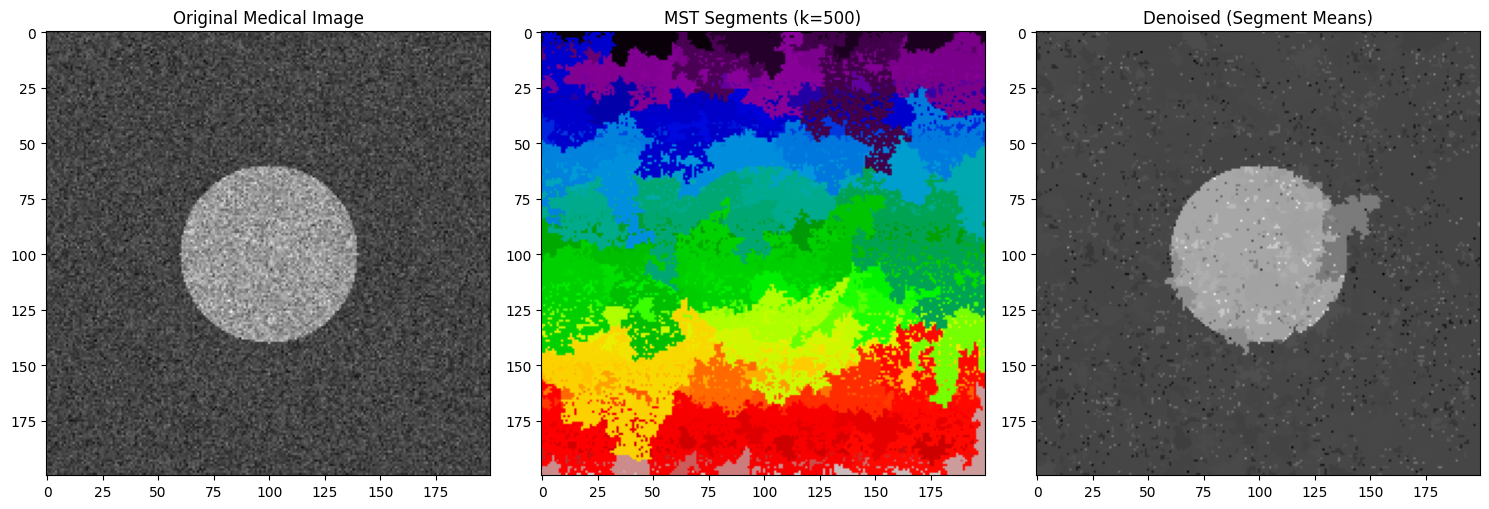

Segmentation completed in 0.5581 seconds.
Total Segments identified: 2253


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
import time

class UnionFind:
    """
    Implements the Union-Find data structure for component management.
    Includes tracking for component size and internal difference (max weight). # [cite: 104, 111]
    """
    def __init__(self, n):
        self.parent = np.arange(n)
        self.size = np.ones(n)
        self.max_weight = np.zeros(n)

    def find(self, i):
        if self.parent[i] == i:
            return i
        self.parent[i] = self.find(self.parent[i]) # Path compression
        return self.parent[i]

    def union(self, root_i, root_j, weight):
        """Merges two components and updates the internal difference. # [cite: 104]"""
        if self.size[root_i] < self.size[root_j]:
            root_i, root_j = root_j, root_i
        self.parent[root_j] = root_i
        self.size[root_i] += self.size[root_j]
        self.max_weight[root_i] = weight

def get_threshold(size, k):
    """Threshold function tau(C) = k / |C|. # [cite: 112]"""
    return k / size

def segment_image(img, k):
    """
    Implements the modified Kruskal's algorithm for segmentation. # [cite: 90, 104]
    """
    height, width = img.shape
    num_pixels = height * width

    # 1. Graph Construction: 4-neighbor connectivity # [cite: 84, 127]
    edges = []
    for y in range(height):
        for x in range(width):
            curr = y * width + x
            if x < width - 1: # Right neighbor
                w = abs(float(img[y, x]) - float(img[y, x+1])) # [cite: 99]
                edges.append((curr, curr + 1, w))
            if y < height - 1: # Bottom neighbor
                w = abs(float(img[y, x]) - float(img[y+1, x])) # [cite: 99]
                edges.append((curr, curr + width, w))

    # 2. Sort edges by weight in non-decreasing order # [cite: 104, 138]
    edges.sort(key=lambda x: x[2])

    # 3. Apply Modified Kruskal's # [cite: 104, 135]
    uf = UnionFind(num_pixels)
    for u, v, w in edges:
        root_u = uf.find(u)
        root_v = uf.find(v)

        if root_u != root_v:
            # canMerge criterion: w(e) <= min(Int(Cu) + tau(Cu), Int(Cv) + tau(Cv)) # [cite: 110]
            thresh_u = uf.max_weight[root_u] + get_threshold(uf.size[root_u], k)
            thresh_v = uf.max_weight[root_v] + get_threshold(uf.size[root_v], k)

            if w <= min(thresh_u, thresh_v):
                uf.union(root_u, root_v, w)

    # Create the segment map
    return np.array([uf.find(i) for i in range(num_pixels)]).reshape(height, width)

def apply_denoising(img, segment_map):
    """
    Replaces pixel values with the mean intensity of their segment. # [cite: 116, 140]
    """
    denoised = np.zeros_like(img, dtype=float)
    unique_segments = np.unique(segment_map)

    for seg_id in unique_segments:
        mask = (segment_map == seg_id)
        denoised[mask] = np.mean(img[mask]) # [cite: 142, 143]
    return denoised

# --- Main Execution Script ---
if __name__ == "__main__":
    # Parameters # [cite: 113, 168]
    K_VALUE = 500  # Scale parameter

    # Load and preprocess image # [cite: 129]
    # Using the previously generated synthetic_mri_image
    img_input = synthetic_mri_image

    # Run Algorithm
    start = time.time()
    seg_map = segment_image(img_input, K_VALUE)
    denoised_img = apply_denoising(img_input, seg_map)
    duration = time.time() - start # [cite: 173]

    # Visualizations # [cite: 146]
    plt.figure(figsize=(15, 5))
    plt.subplot(131), plt.imshow(img_input, cmap='gray'), plt.title("Original Medical Image")
    plt.subplot(132), plt.imshow(seg_map, cmap='nipy_spectral'), plt.title(f"MST Segments (k={K_VALUE})")
    plt.subplot(133), plt.imshow(denoised_img, cmap='gray'), plt.title("Denoised (Segment Means)")
    plt.tight_layout()
    plt.show()

    print(f"Segmentation completed in {duration:.4f} seconds.") # [cite: 173]
    print(f"Total Segments identified: {len(np.unique(seg_map))}") # [cite: 172]

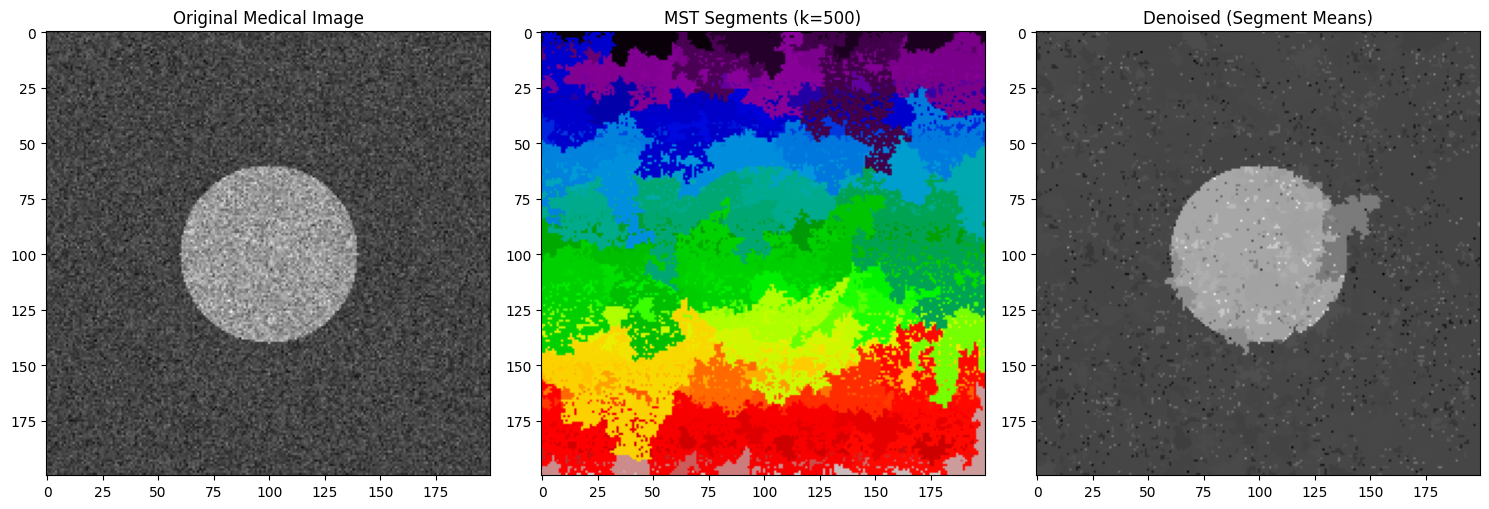

Segmentation completed in 0.5581 seconds.
Total Segments identified: 2253


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
import time

class UnionFind:
    """
    Implements the Union-Find data structure for component management.
    Includes tracking for component size and internal difference (max weight). # [cite: 104, 111]
    """
    def __init__(self, n):
        self.parent = np.arange(n)
        self.size = np.ones(n)
        self.max_weight = np.zeros(n)

    def find(self, i):
        if self.parent[i] == i:
            return i
        self.parent[i] = self.find(self.parent[i]) # Path compression
        return self.parent[i]

    def union(self, root_i, root_j, weight):
        """Merges two components and updates the internal difference. # [cite: 104]"""
        if self.size[root_i] < self.size[root_j]:
            root_i, root_j = root_j, root_i
        self.parent[root_j] = root_i
        self.size[root_i] += self.size[root_j]
        self.max_weight[root_i] = weight

def get_threshold(size, k):
    """Threshold function tau(C) = k / |C|. # [cite: 112]"""
    return k / size

def segment_image(img, k):
    """
    Implements the modified Kruskal's algorithm for segmentation. # [cite: 90, 104]
    """
    height, width = img.shape
    num_pixels = height * width

    # 1. Graph Construction: 4-neighbor connectivity # [cite: 84, 127]
    edges = []
    for y in range(height):
        for x in range(width):
            curr = y * width + x
            if x < width - 1: # Right neighbor
                w = abs(float(img[y, x]) - float(img[y, x+1])) # [cite: 99]
                edges.append((curr, curr + 1, w))
            if y < height - 1: # Bottom neighbor
                w = abs(float(img[y, x]) - float(img[y+1, x])) # [cite: 99]
                edges.append((curr, curr + width, w))

    # 2. Sort edges by weight in non-decreasing order # [cite: 104, 138]
    edges.sort(key=lambda x: x[2])

    # 3. Apply Modified Kruskal's # [cite: 104, 135]
    uf = UnionFind(num_pixels)
    for u, v, w in edges:
        root_u = uf.find(u)
        root_v = uf.find(v)

        if root_u != root_v:
            # canMerge criterion: w(e) <= min(Int(Cu) + tau(Cu), Int(Cv) + tau(Cv)) # [cite: 110]
            thresh_u = uf.max_weight[root_u] + get_threshold(uf.size[root_u], k)
            thresh_v = uf.max_weight[root_v] + get_threshold(uf.size[root_v], k)

            if w <= min(thresh_u, thresh_v):
                uf.union(root_u, root_v, w)

    # Create the segment map
    return np.array([uf.find(i) for i in range(num_pixels)]).reshape(height, width)

def apply_denoising(img, segment_map):
    """
    Replaces pixel values with the mean intensity of their segment. # [cite: 116, 140]
    """
    denoised = np.zeros_like(img, dtype=float)
    unique_segments = np.unique(segment_map)

    for seg_id in unique_segments:
        mask = (segment_map == seg_id)
        denoised[mask] = np.mean(img[mask]) # [cite: 142, 143]
    return denoised

# --- Main Execution Script ---
if __name__ == "__main__":
    # Parameters # [cite: 113, 168]
    K_VALUE = 500  # Scale parameter

    # Load and preprocess image # [cite: 129]
    # Using the previously generated synthetic_mri_image
    img_input = synthetic_mri_image

    # Run Algorithm
    start = time.time()
    seg_map = segment_image(img_input, K_VALUE)
    denoised_img = apply_denoising(img_input, seg_map)
    duration = time.time() - start # [cite: 173]

    # Visualizations # [cite: 146]
    plt.figure(figsize=(15, 5))
    plt.subplot(131), plt.imshow(img_input, cmap='gray'), plt.title("Original Medical Image")
    plt.subplot(132), plt.imshow(seg_map, cmap='nipy_spectral'), plt.title(f"MST Segments (k={K_VALUE})")
    plt.subplot(133), plt.imshow(denoised_img, cmap='gray'), plt.title("Denoised (Segment Means)")
    plt.tight_layout()
    plt.show()

    print(f"Segmentation completed in {duration:.4f} seconds.") # [cite: 173]
    print(f"Total Segments identified: {len(np.unique(seg_map))}") # [cite: 172]

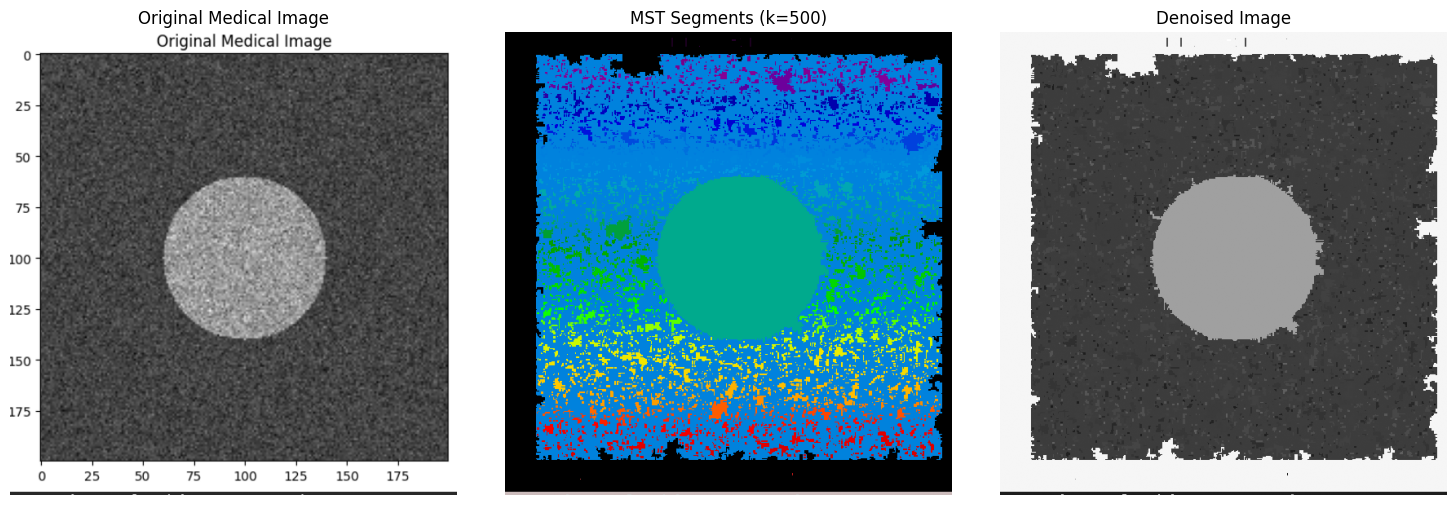

Segmentation completed in 4.5009 seconds.
Total Segments identified: 3424


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import time


class UnionFind:
    """
    Union-Find structure for managing components.
    Tracks component size and maximum internal edge weight.
    """

    def __init__(self, n):
        self.parent = np.arange(n)
        self.size = np.ones(n)
        self.max_weight = np.zeros(n)

    def find(self, i):
        if self.parent[i] == i:
            return i
        self.parent[i] = self.find(self.parent[i])  # Path compression
        return self.parent[i]

    def union(self, root_i, root_j, weight):
        """Merge two components"""
        if self.size[root_i] < self.size[root_j]:
            root_i, root_j = root_j, root_i

        self.parent[root_j] = root_i
        self.size[root_i] += self.size[root_j]
        self.max_weight[root_i] = weight


def get_threshold(size, k):
    """Threshold function tau(C) = k / |C|"""
    return k / size


def segment_image(img, k):
    """
    Modified Kruskal's algorithm for graph-based image segmentation.
    """

    height, width = img.shape
    num_pixels = height * width

    edges = []

    # Graph construction (4-neighbour connectivity)
    for y in range(height):
        for x in range(width):

            current = y * width + x

            if x < width - 1:
                w = abs(float(img[y, x]) - float(img[y, x + 1]))
                edges.append((current, current + 1, w))

            if y < height - 1:
                w = abs(float(img[y, x]) - float(img[y + 1, x]))
                edges.append((current, current + width, w))

    # Sort edges by weight
    edges.sort(key=lambda x: x[2])

    # Initialize Union-Find
    uf = UnionFind(num_pixels)

    # Apply modified Kruskal
    for u, v, w in edges:

        root_u = uf.find(u)
        root_v = uf.find(v)

        if root_u != root_v:

            thresh_u = uf.max_weight[root_u] + get_threshold(uf.size[root_u], k)
            thresh_v = uf.max_weight[root_v] + get_threshold(uf.size[root_v], k)

            if w <= min(thresh_u, thresh_v):
                uf.union(root_u, root_v, w)

    # Create segmentation map
    segment_map = np.array([uf.find(i) for i in range(num_pixels)])
    return segment_map.reshape(height, width)


def apply_denoising(img, segment_map):
    """
    Replace pixel values with the mean intensity of their segment.
    """

    denoised = np.zeros_like(img, dtype=float)

    segments = np.unique(segment_map)

    for seg in segments:

        mask = (segment_map == seg)

        denoised[mask] = np.mean(img[mask])

    return denoised


# ---------------- MAIN PROGRAM ----------------

if __name__ == "__main__":

    K_VALUE = 500

    # Load grayscale image
    img_input = io.imread("/content/sample_data/mri_image.png", as_gray=True)

    start = time.time()

    seg_map = segment_image(img_input, K_VALUE)

    denoised_img = apply_denoising(img_input, seg_map)

    duration = time.time() - start

    # Visualization
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_input, cmap='gray')
    plt.title("Original Medical Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(seg_map, cmap='nipy_spectral')
    plt.title(f"MST Segments (k={K_VALUE})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(denoised_img, cmap='gray')
    plt.title("Denoised Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Segmentation completed in {duration:.4f} seconds.")
    print(f"Total Segments identified: {len(np.unique(seg_map))}")

The `synthetic_mri_image` variable now holds the generated synthetic medical image. You can use this image for further processing or visualization.